✅ Data loaded
Shape: (117430, 39)
Train: 93944 | Test: 23486

Training Models...

📊 RESULTS:
--------------------------------------------------
Model                Accuracy     Precision    Recall       ROC-AUC     
--------------------------------------------------
Logistic Regression  0.7694       0.8832       0.4460       0.7939      
Random Forest        0.8278       0.8146       0.7020       0.8895      

🏆 BEST MODEL: Random Forest (ROC-AUC: 0.8895)

📊 TOP 5 FACTORS AFFECTING CANCELLATIONS:
   1. lead_time: 0.281
   2. deposit_type: 0.185
   3. adr: 0.158
   4. adr_per_person: 0.149
   5. total_stay: 0.076


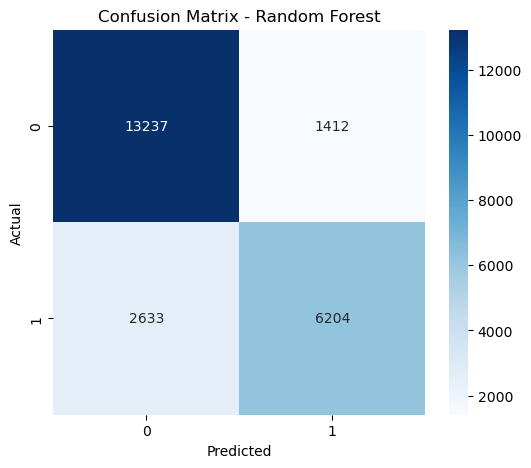

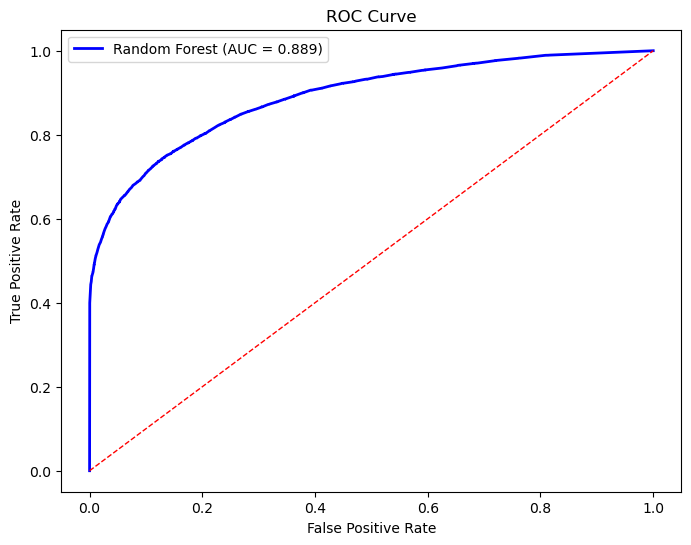

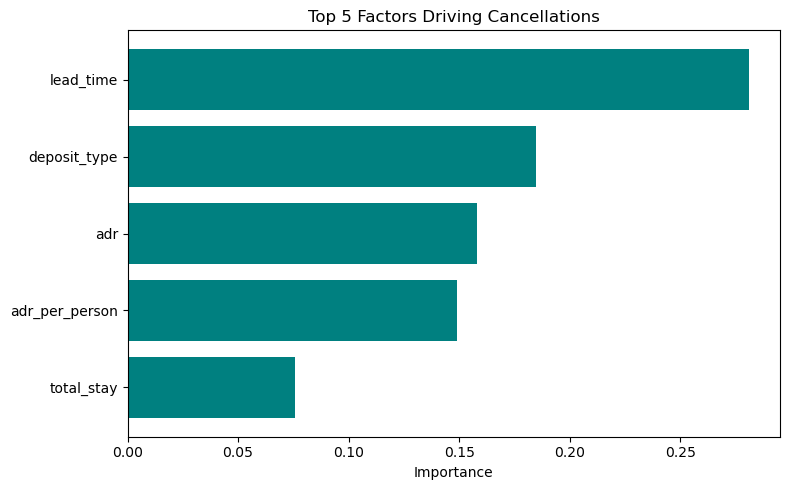


WEEK 3 SUMMARY

✅ Best Model: Random Forest
✅ ROC-AUC Score: 0.8895 (88.9%)
✅ Accuracy: 0.8278
✅ Recall: 0.7020

📌 KEY DRIVERS OF CANCELLATION:
   1. lead_time
   2. deposit_type
   3. adr

💡 BUSINESS RECOMMENDATIONS:
   • Use Random Forest to predict cancellations in real-time
   • Focus retention efforts on high-risk bookings
   • Monitor lead_time as primary indicator

🎉 WEEK 3 COMPLETED!


In [2]:
# WEEK 3: Cancellation Prediction Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve

# Load data
df = pd.read_csv('C:/Users/achar/OneDrive/Documents/GitHub/data-analytics-projects/Travel-Hospitality-Project/Data/hotel_bookings.csv')

print("✅ Data loaded")
print(f"Shape: {df.shape}")

# Select features
features = ['lead_time', 'total_stay', 'total_guests', 'adr', 'adr_per_person', 
            'booking_changes', 'total_of_special_requests', 'previous_cancellations']

# Add encoded categorical features
df['hotel_encoded'] = df['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})
df['deposit_encoded'] = df['deposit_type'].map({'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})

# Prepare X and y
X = df[features + ['hotel_encoded', 'deposit_encoded']].copy()
y = df['is_canceled'].copy()

# Handle any missing values
X = X.fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Train models
print("\n" + "="*50)
print("Training Models...")
print("="*50)

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# Results
print("\n📊 RESULTS:")
print("-"*50)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'ROC-AUC':<12}")
print("-"*50)
print(f"{'Logistic Regression':<20} {accuracy_score(y_test, lr_pred):<12.4f} {precision_score(y_test, lr_pred):<12.4f} {recall_score(y_test, lr_pred):<12.4f} {roc_auc_score(y_test, lr_proba):<12.4f}")
print(f"{'Random Forest':<20} {accuracy_score(y_test, rf_pred):<12.4f} {precision_score(y_test, rf_pred):<12.4f} {recall_score(y_test, rf_pred):<12.4f} {roc_auc_score(y_test, rf_proba):<12.4f}")

# Find best model
best_model = rf if roc_auc_score(y_test, rf_proba) > roc_auc_score(y_test, lr_proba) else lr
best_name = "Random Forest" if best_model == rf else "Logistic Regression"
best_score = max(roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, lr_proba))

print(f"\n🏆 BEST MODEL: {best_name} (ROC-AUC: {best_score:.4f})")

# Feature Importance (Random Forest)
print("\n📊 TOP 5 FACTORS AFFECTING CANCELLATIONS:")
feature_names = features + ['hotel_type', 'deposit_type']
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

for i in range(5):
    print(f"   {i+1}. {importance.iloc[i]['Feature']}: {importance.iloc[i]['Importance']:.3f}")

# Confusion Matrix for best model
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'{best_name} (AUC = {best_score:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature Importance Chart
plt.figure(figsize=(8, 5))
top5 = importance.head(5)
plt.barh(top5['Feature'], top5['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Top 5 Factors Driving Cancellations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*50)
print("WEEK 3 SUMMARY")
print("="*50)
print(f"""
✅ Best Model: {best_name}
✅ ROC-AUC Score: {best_score:.4f} ({best_score*100:.1f}%)
✅ Accuracy: {accuracy_score(y_test, best_model.predict(X_test)):.4f}
✅ Recall: {recall_score(y_test, best_model.predict(X_test)):.4f}

📌 KEY DRIVERS OF CANCELLATION:
   1. {importance.iloc[0]['Feature']}
   2. {importance.iloc[1]['Feature']}
   3. {importance.iloc[2]['Feature']}

💡 BUSINESS RECOMMENDATIONS:
   • Use {best_name} to predict cancellations in real-time
   • Focus retention efforts on high-risk bookings
   • Monitor {importance.iloc[0]['Feature']} as primary indicator
""")

print("🎉 WEEK 3 COMPLETED!")